# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrantes:** Camilo Zapata Cárdenas  
**Correos:** camilo.zapata97@eia.edu.co  
**Fecha:** 2026-08-20

## Objetivo

Comparar Q-Learning tabular con cuatro estrategias de exploración en FrozenLake, Blackjack y Taxi.

## 1. Preparación y reconocimiento de escenarios

In [1]:
from __future__ import annotations

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30
ENV_CONFIG = {
    'FrozenLake-v1': {'episodes': 2_000, 'max_steps': 100, 'kwargs': {'is_slippery': True}},
    'Blackjack-v1': {'episodes': 10_000, 'max_steps': 100, 'kwargs': {'sab': True}},
    'Taxi-v4': {'episodes': 2_000, 'max_steps': 200, 'kwargs': {}},
}
STRATEGIES = {
    'epsilon_greedy': {'epsilon': 0.10, 'q0': 0.0},
    'optimistic': {'epsilon': 0.01, 'q0': 5.0},
    'ucb': {'c': 1.0, 'q0': 0.0},
    'softmax': {'temperature': 0.50, 'q0': 0.0},
}

def tabular_space_size(space):
    if isinstance(space, gym.spaces.Discrete):
        return int(space.n)
    if isinstance(space, gym.spaces.Tuple):
        return int(np.prod([item.n for item in space.spaces]))
    raise TypeError('Este reto solo admite observaciones discretas.')

def encode_observation(observation, space):
    if isinstance(space, gym.spaces.Discrete):
        return int(observation)
    return int(np.ravel_multi_index(tuple(observation), tuple(item.n for item in space.spaces)))

scenario_rows = []
for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config['kwargs'])
    observation, _ = env.reset(seed=SEED)
    scenario_rows.append({'Entorno': env_id, 'Estados': tabular_space_size(env.observation_space), 'Acciones': env.action_space.n, 'Observación inicial': str(observation)})
    env.close()
pd.DataFrame(scenario_rows).set_index('Entorno')

Matplotlib is building the font cache; this may take a moment.


,Estados,Acciones,Observación inicial
Entorno,,,
FrozenLake-v1,16,4,0
Blackjack-v1,704,2,"(20, 10, 1)"
Taxi-v4,500,6,87


## 2. Estrategias de exploración

In [2]:
def random_argmax(values, rng):
    candidates = np.flatnonzero(values == np.max(values))
    return int(rng.choice(candidates))

def select_action(q, counts, state, strategy, rng, *, epsilon=0.10, c=1.0, temperature=0.50):
    if strategy not in {'epsilon_greedy', 'optimistic', 'ucb', 'softmax'}:
        raise ValueError('Estrategia desconocida.')
    if not 0 <= epsilon <= 1:
        raise ValueError('epsilon debe estar entre 0 y 1.')
    if c < 0:
        raise ValueError('c debe ser mayor o igual que 0.')
    if temperature <= 0:
        raise ValueError('temperature debe ser positiva.')
    values = q[state]
    if strategy in {'epsilon_greedy', 'optimistic'}:
        return int(rng.integers(q.shape[1])) if rng.random() < epsilon else random_argmax(values, rng)
    if strategy == 'ucb':
        unvisited = np.flatnonzero(counts[state] == 0)
        if unvisited.size:
            return int(rng.choice(unvisited))
        bonus = c * np.sqrt(np.log(counts[state].sum() + 1) / counts[state])
        return random_argmax(values + bonus, rng)
    logits = values / temperature
    weights = np.exp(logits - np.max(logits))
    return int(rng.choice(q.shape[1], p=weights / weights.sum()))

q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])
assert select_action(q_test, n_test, 0, 'ucb', np.random.default_rng(SEED)) == 3
assert all(0 <= select_action(q_test, n_test, 0, 'epsilon_greedy', np.random.default_rng(seed)) < 4 for seed in range(20))
print('Pruebas de selección superadas.')

Pruebas de selección superadas.


## 3. Q-Learning tabular y evaluación greedy

In [3]:
def is_success(env_id, episode_return, terminal_reward):
    if env_id in {'FrozenLake-v1', 'Blackjack-v1'}:
        return int(episode_return == 1)
    return int(terminal_reward > 0)

def train_q_learning(env_id, strategy, episodes, max_steps, alpha, gamma, seed, env_kwargs=None, **strategy_params):
    if episodes <= 0 or max_steps <= 0 or not 0 < alpha <= 1 or not 0 <= gamma <= 1:
        raise ValueError('Parámetros de entrenamiento inválidos.')
    env = gym.make(env_id, **(env_kwargs or {}))
    rng = np.random.default_rng(seed)
    try:
        q = np.full((tabular_space_size(env.observation_space), env.action_space.n), float(strategy_params.get('q0', 0.0)))
        counts = np.zeros_like(q, dtype=int)
        action_params = {key: value for key, value in strategy_params.items() if key in {'epsilon', 'c', 'temperature'}}
        rows = []
        for episode in range(episodes):
            observation, _ = env.reset(seed=seed + episode)
            state = encode_observation(observation, env.observation_space)
            total_return, terminal_reward, td_errors = 0.0, 0.0, []
            for step in range(1, max_steps + 1):
                action = select_action(q, counts, state, strategy, rng, **action_params)
                next_observation, reward, terminated, truncated, _ = env.step(action)
                next_state = encode_observation(next_observation, env.observation_space)
                counts[state, action] += 1
                target = reward if terminated else reward + gamma * np.max(q[next_state])
                td_error = target - q[state, action]
                q[state, action] += alpha * td_error
                total_return += reward
                terminal_reward = reward
                td_errors.append(abs(td_error))
                state = next_state
                if terminated or truncated:
                    break
            rows.append({'episode': episode + 1, 'return': total_return, 'length': step, 'success': is_success(env_id, total_return, terminal_reward), 'td_error_mean': float(np.mean(td_errors))})
        return q, pd.DataFrame(rows), counts
    finally:
        env.close()

def evaluate_policy(env_id, q, n_episodes, max_steps, seed, env_kwargs=None):
    env = gym.make(env_id, **(env_kwargs or {}))
    rng = np.random.default_rng(seed)
    try:
        rows = []
        for episode in range(n_episodes):
            observation, _ = env.reset(seed=seed + episode)
            state = encode_observation(observation, env.observation_space)
            total_return, terminal_reward = 0.0, 0.0
            for step in range(1, max_steps + 1):
                action = random_argmax(q[state], rng)
                observation, reward, terminated, truncated, _ = env.step(action)
                state = encode_observation(observation, env.observation_space)
                total_return += reward
                terminal_reward = reward
                if terminated or truncated:
                    break
            rows.append({'episode': episode + 1, 'return': total_return, 'length': step, 'success': is_success(env_id, total_return, terminal_reward)})
        return pd.DataFrame(rows)
    finally:
        env.close()

short_q, short_history, short_counts = train_q_learning('FrozenLake-v1', 'epsilon_greedy', 20, 100, ALPHA, GAMMA, SEED, {'is_slippery': True}, **STRATEGIES['epsilon_greedy'])
assert short_q.shape == (16, 4) and np.isfinite(short_q).all()
assert len(short_history) == 20 and short_history['length'].between(1, 100).all()
assert short_counts.sum() == short_history['length'].sum()
q_copy = short_q.copy()
_ = evaluate_policy('FrozenLake-v1', short_q, 5, 100, 1_000_000 + SEED, {'is_slippery': True})
np.testing.assert_array_equal(short_q, q_copy)
print('Verificaciones de Q-Learning superadas.')

Verificaciones de Q-Learning superadas.


## 4. Piloto en FrozenLake

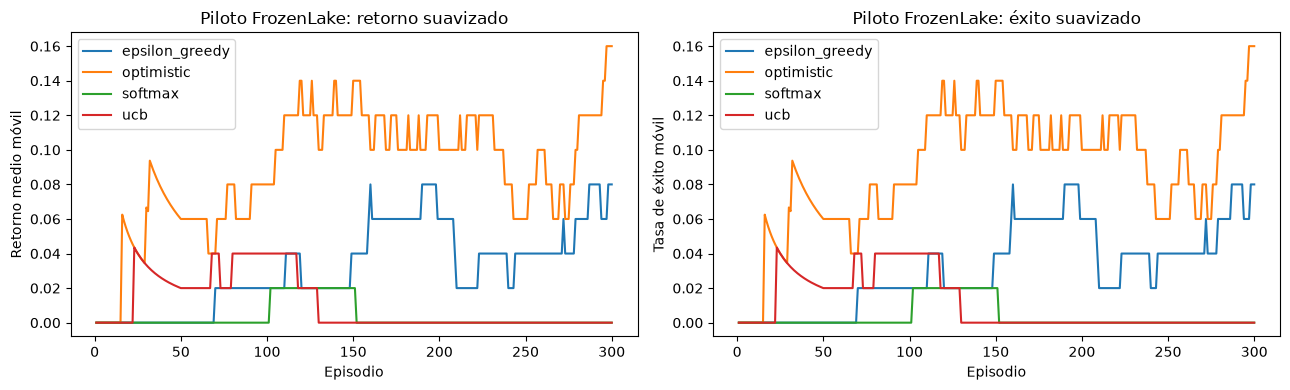

In [4]:
pilot_rows = []
for name, params in STRATEGIES.items():
    _, history, _ = train_q_learning('FrozenLake-v1', name, 300, 100, ALPHA, GAMMA, SEED, {'is_slippery': True}, **params)
    history['algorithm'] = name
    pilot_rows.append(history)
pilot_results = pd.concat(pilot_rows, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, data in pilot_results.groupby('algorithm'):
    axes[0].plot(data['episode'], data['return'].rolling(50, min_periods=1).mean(), label=name)
    axes[1].plot(data['episode'], data['success'].rolling(50, min_periods=1).mean(), label=name)
axes[0].set(title='Piloto FrozenLake: retorno suavizado', xlabel='Episodio', ylabel='Retorno medio móvil')
axes[1].set(title='Piloto FrozenLake: éxito suavizado', xlabel='Episodio', ylabel='Tasa de éxito móvil')
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()

## 5. Comparación principal

In [5]:
def run_experiment(env_config, strategies, n_runs=N_RUNS, base_seed=SEED):
    training_frames, evaluation_frames = [], []
    for env_id, config in env_config.items():
        for name, params in strategies.items():
            for run in range(n_runs):
                train_seed = base_seed + run
                q, history, _ = train_q_learning(env_id, name, config['episodes'], config['max_steps'], ALPHA, GAMMA, train_seed, config['kwargs'], **params)
                history['environment'] = env_id; history['algorithm'] = name; history['run'] = run
                training_frames.append(history)
                evaluation = evaluate_policy(env_id, q, 100, config['max_steps'], 1_000_000 + train_seed, config['kwargs'])
                evaluation['environment'] = env_id; evaluation['algorithm'] = name; evaluation['run'] = run
                evaluation_frames.append(evaluation)
    return pd.concat(training_frames, ignore_index=True), pd.concat(evaluation_frames, ignore_index=True)

training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)

## 6. Métricas y visualizaciones

run_mean  run_confidence_half_width  \
environment   algorithm                                             
Blackjack-v1  epsilon_greedy      14.5                       3.15   
              optimistic          14.5                       3.15   
              softmax             14.5                       3.15   
              ucb                 14.5                       3.15   
FrozenLake-v1 epsilon_greedy      14.5                       3.15   
              optimistic          14.5                       3.15   
              softmax             14.5                       3.15   
              ucb                 14.5                       3.15   
Taxi-v4       epsilon_greedy      14.5                       3.15   
              optimistic          14.5                       3.15   
              softmax             14.5                       3.15   
              ucb                 14.5                       3.15   

                              last_10_percent_return_mean  \
environment   algorithm                                     
Blackjack-v1  epsilon_greedy                       -0.110   
              optimistic                           -0.152   
              softmax                              -0.169   
              ucb                                  -0.108   
FrozenLake-v1 epsilon_greedy                        0.351   
              optimistic                            0.641   
              softmax                               0.017   
              ucb                                   0.346   
Taxi-v4       epsilon_greedy                        1.552   
              optimistic                            6.160   
              softmax                               4.538   
              ucb                                   6.982   

                              last_10_percent_return_confidence_half_width  \
environment   algorithm                                                      
Blackjack-v1  epsilon_greedy                                         0.007   
              optimistic                                             0.005   
              softmax                                                0.008   
              ucb                                                    0.005   
FrozenLake-v1 epsilon_greedy                                         0.026   
              optimistic                                             0.011   
              softmax                                                0.004   
              ucb                                                    0.060   
Taxi-v4       epsilon_greedy                                         0.201   
              optimistic                                             0.105   
              softmax                                                0.209   
              ucb                                                    0.077   

                              training_auc_mean  \
environment   algorithm                           
Blackjack-v1  epsilon_greedy          -1300.133   
              optimistic              -2263.417   
              softmax                 -2089.433   
              ucb                     -1483.417   
FrozenLake-v1 epsilon_greedy            422.850   
              optimistic                902.817   
              softmax                    32.067   
              ucb                       343.650   
Taxi-v4       epsilon_greedy        -108133.100   
              optimistic            -100139.283   
              softmax               -149127.683   
              ucb                   -104989.900   

                              training_auc_confidence_half_width  \
environment   algorithm                                            
Blackjack-v1  epsilon_greedy                              24.104   
              optimistic                                  16.136   
              softmax                                     27.445   
              ucb                                         16

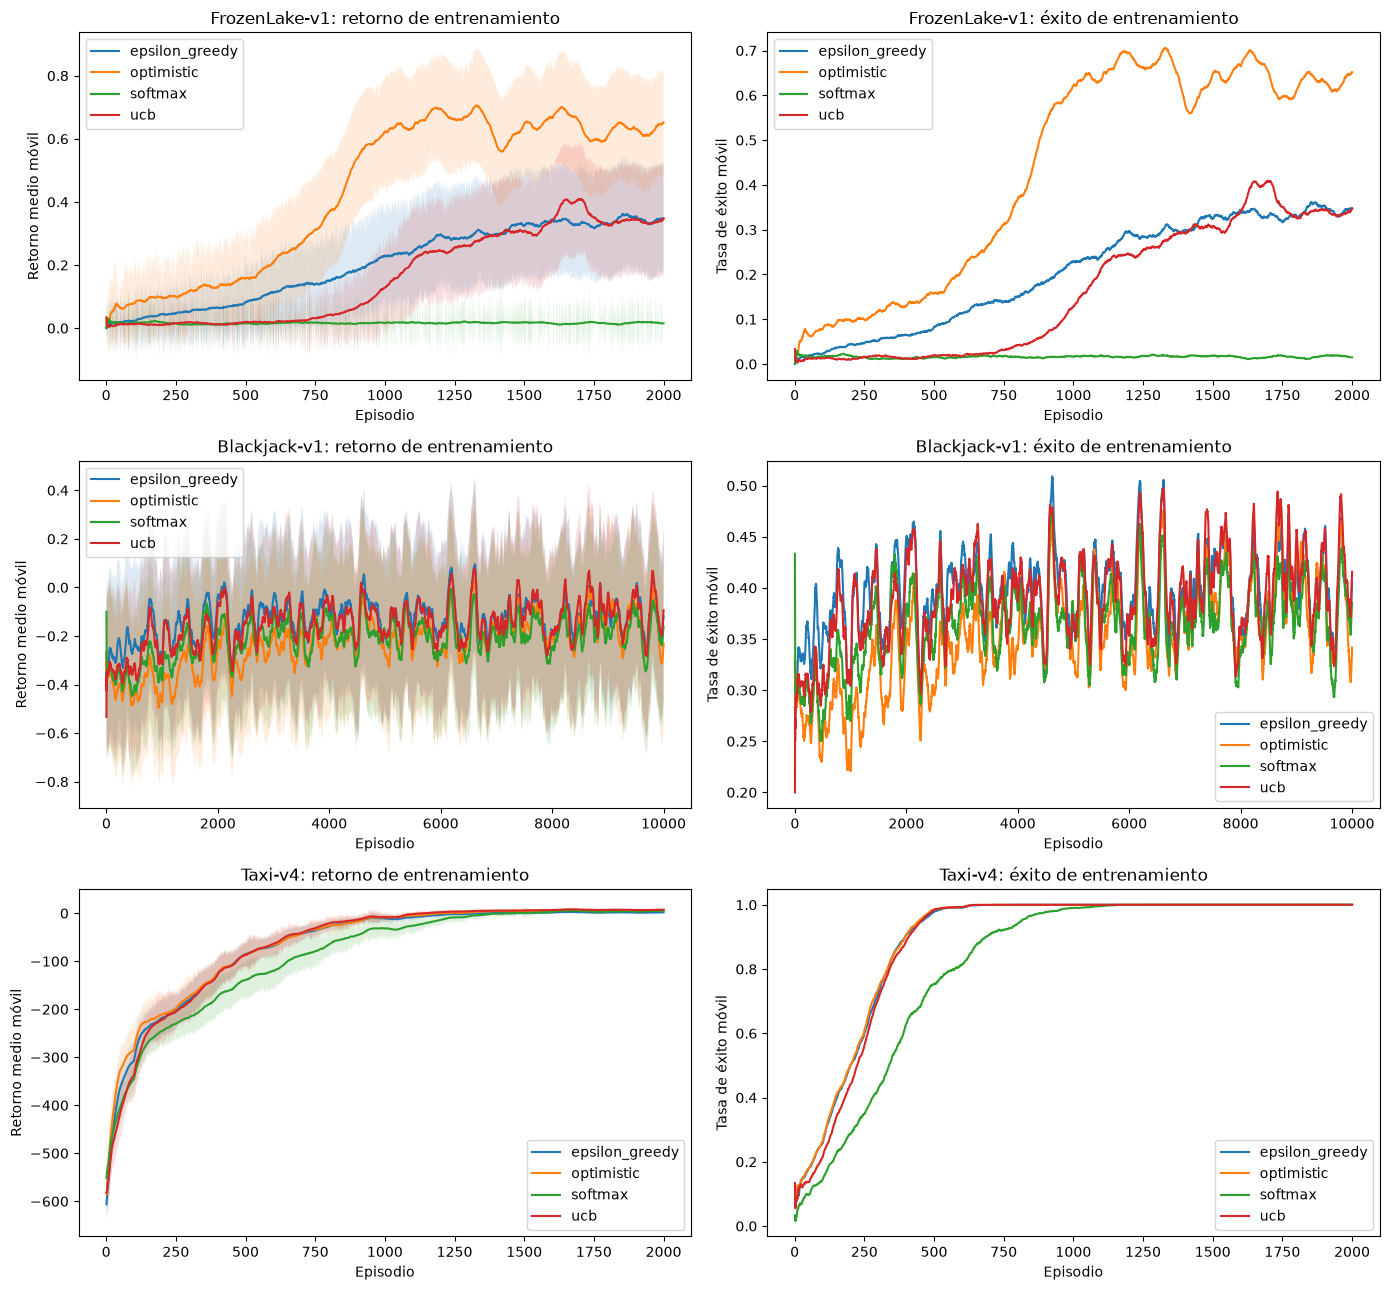

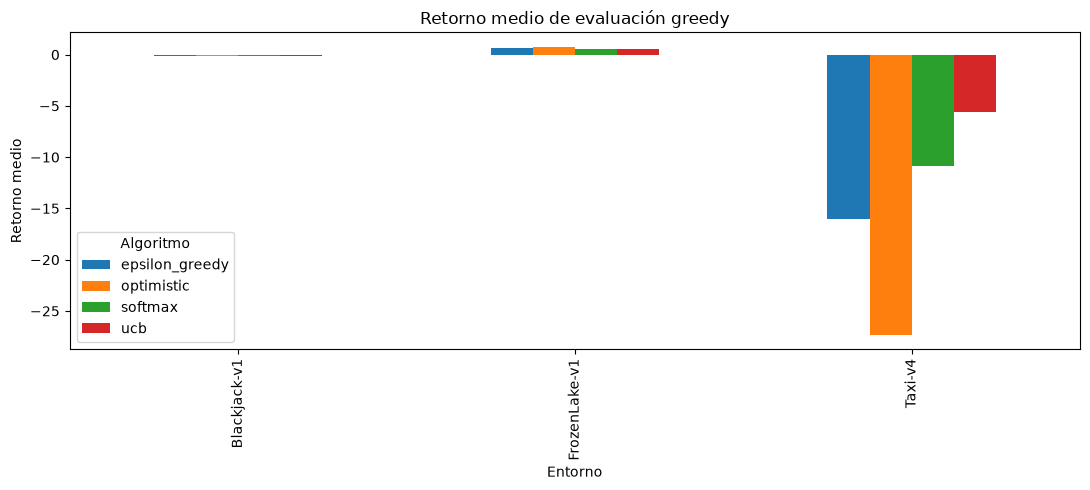

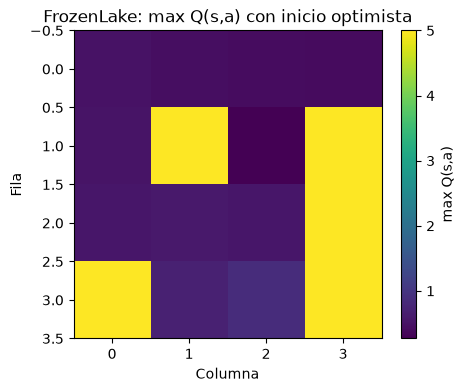

In [6]:
def confidence_half_width(values):
    return 1.96 * values.std(ddof=1) / np.sqrt(len(values))

last_start = training_results.groupby(['environment', 'run'])['episode'].transform('max') * 0.9
last_training = training_results[training_results['episode'] > last_start]
last_metrics = last_training.groupby(['environment', 'algorithm', 'run'])['return'].mean().rename('last_10_percent_return')
auc_metrics = training_results.groupby(['environment', 'algorithm', 'run']).apply(lambda data: np.trapezoid(data['return'].to_numpy()), include_groups=False).rename('training_auc')
evaluation_by_run = evaluation_results.groupby(['environment', 'algorithm', 'run']).agg(success_rate=('success', 'mean'), evaluation_return=('return', 'mean'), evaluation_length=('length', 'mean'))
metrics_by_run = pd.concat([last_metrics, auc_metrics, evaluation_by_run], axis=1).reset_index()
summary_df = metrics_by_run.groupby(['environment', 'algorithm']).agg(['mean', confidence_half_width])
summary_df.columns = ['_'.join(column) for column in summary_df.columns]
display(summary_df.round(3))

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for row, env_id in enumerate(ENV_CONFIG):
    environment_data = training_results[training_results['environment'] == env_id]
    for name, data in environment_data.groupby('algorithm'):
        mean_return = data.groupby('episode')['return'].mean()
        smooth = mean_return.rolling(100, min_periods=1).mean()
        sem = data.groupby('episode')['return'].sem().fillna(0)
        axes[row, 0].plot(mean_return.index, smooth, label=name)
        axes[row, 0].fill_between(mean_return.index, smooth - 1.96 * sem, smooth + 1.96 * sem, alpha=0.15)
        success = data.groupby('episode')['success'].mean().rolling(100, min_periods=1).mean()
        axes[row, 1].plot(success.index, success, label=name)
    axes[row, 0].set(title=env_id + ': retorno de entrenamiento', xlabel='Episodio', ylabel='Retorno medio móvil')
    axes[row, 1].set(title=env_id + ': éxito de entrenamiento', xlabel='Episodio', ylabel='Tasa de éxito móvil')
    axes[row, 0].legend(); axes[row, 1].legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
evaluation_summary = metrics_by_run.groupby(['environment', 'algorithm'])['evaluation_return'].mean().unstack()
evaluation_summary.plot(kind='bar', ax=ax)
ax.set(title='Retorno medio de evaluación greedy', xlabel='Entorno', ylabel='Retorno medio'); ax.legend(title='Algoritmo'); plt.tight_layout(); plt.show()

policy_q, _, _ = train_q_learning('FrozenLake-v1', 'optimistic', 2_000, 100, ALPHA, GAMMA, SEED, {'is_slippery': True}, **STRATEGIES['optimistic'])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(np.max(policy_q, axis=1).reshape(4, 4), cmap='viridis')
ax.set(title='FrozenLake: max Q(s,a) con inicio optimista', xlabel='Columna', ylabel='Fila')
fig.colorbar(image, ax=ax, label='max Q(s,a)'); plt.show()

## 7. Sensibilidad de hiperparámetros

,strategy,parameter,value,retorno_medio,éxito_medio
0,epsilon_greedy,epsilon,0.01,0.212,0.212
1,epsilon_greedy,epsilon,0.10,0.700,0.700
2,epsilon_greedy,epsilon,0.30,0.732,0.732
3,optimistic,q0,1.00,0.787,0.787
4,optimistic,q0,5.00,0.763,0.763
5,optimistic,q0,10.00,0.800,0.800
6,softmax,temperature,0.10,0.668,0.668
7,softmax,temperature,0.50,0.510,0.510
8,softmax,temperature,1.00,0.482,0.482
9,ucb,c,0.25,0.427,0.427


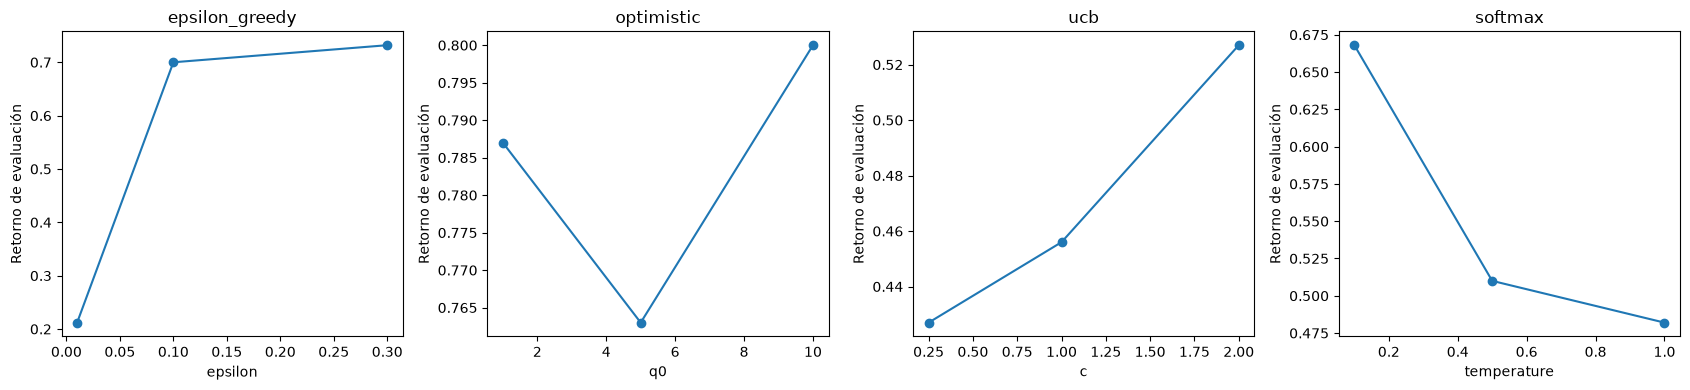

In [7]:
SENSITIVITY_ENV = 'FrozenLake-v1'
SENSITIVITY_RUNS = 10
sensitivity_configs = [
    ('epsilon_greedy', 'epsilon', value, {'epsilon': value, 'q0': 0.0}) for value in [0.01, 0.10, 0.30]
] + [
    ('optimistic', 'q0', value, {'epsilon': 0.01, 'q0': value}) for value in [1.0, 5.0, 10.0]
] + [
    ('ucb', 'c', value, {'c': value, 'q0': 0.0}) for value in [0.25, 1.0, 2.0]
] + [
    ('softmax', 'temperature', value, {'temperature': value, 'q0': 0.0}) for value in [0.10, 0.50, 1.0]
]
sensitivity_rows = []
config = ENV_CONFIG[SENSITIVITY_ENV]
for strategy, parameter, value, params in sensitivity_configs:
    for run in range(SENSITIVITY_RUNS):
        q, _, _ = train_q_learning(SENSITIVITY_ENV, strategy, config['episodes'], config['max_steps'], ALPHA, GAMMA, SEED + run, config['kwargs'], **params)
        evaluation = evaluate_policy(SENSITIVITY_ENV, q, 100, config['max_steps'], 1_000_000 + SEED + run, config['kwargs'])
        sensitivity_rows.append({'strategy': strategy, 'parameter': parameter, 'value': value, 'run': run, 'evaluation_return': evaluation['return'].mean(), 'success_rate': evaluation['success'].mean()})
sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary = sensitivity_df.groupby(['strategy', 'parameter', 'value']).agg(retorno_medio=('evaluation_return', 'mean'), éxito_medio=('success_rate', 'mean')).reset_index()
display(sensitivity_summary.round(3))
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, strategy in zip(axes, STRATEGIES):
    data = sensitivity_summary[sensitivity_summary['strategy'] == strategy]
    ax.plot(data['value'], data['retorno_medio'], marker='o')
    ax.set(title=strategy, xlabel=data['parameter'].iloc[0], ylabel='Retorno de evaluación')
plt.tight_layout(); plt.show()

## 8. Interpretación

1. **Velocidad de aprendizaje.** Si se toma el AUC de entrenamiento como medida de aprendizaje temprano, ε-greedy fue el más rápido en Blackjack (AUC = -1300.1), el inicio optimista en FrozenLake (902.8) y también en Taxi (-100139.3), en FrozenLake esta ventaja además se mantuvo al final, el retorno del último 10 % fue 0.641 para el agente optimista, frente a 0.351 para ε-greedy, en Taxi, UCB terminó con el mayor retorno del último 10 % (6.982), de modo que el ganador durante el aprendizaje no fue necesariamente el de la fase final.

2. **Entrenamiento frente a política greedy.** No siempre coincidieron, en FrozenLake sí, el optimista tuvo el mejor AUC y la mejor evaluación greedy (retorno y éxito = 0.767), en Blackjack, ε-greedy tuvo el mejor AUC, pero Softmax obtuvo por poco el retorno greedy menos negativo (-0.113 frente a -0.117), sus IC se solapan, así que no es evidencia de una superioridad, en Taxi, el optimista tuvo el mejor AUC, pero UCB produjo la mejor política final: retorno de evaluación -5.580 y éxito 0.935, separar entrenamiento y evaluación permitió ver esa diferencia.

3. **Efecto del optimismo.** La inicialización con `Q0 = 5` ayudó claramente en FrozenLake, donde las recompensas son escasas y no negativas, alcanzó 0.767 de éxito frente a 0.679 con ε-greedy, también acumuló el mejor desempeño de entrenamiento en Taxi, pero allí perjudicó la política final (-27.309 de retorno de evaluación y 0.881 de éxito), en Taxi, acciones todavía no actualizadas parecen tener un valor muy alto aunque puedan generar penalizaciones de -10, se requieren muchas experiencias para corregir ese optimismo, en Blackjack, cuyo retorno está entre -1 y 1, `Q0 = 5` está aún más desalineado con la escala de recompensas y fue la peor curva (AUC = -2263.4), los estados poco visitados conservan valores optimistas por más tiempo, lo cual explica que el mecanismo no tenga el mismo efecto en los tres entornos.

4. **UCB y conteos locales.** UCB fuerza explorar cada acción no visitada en el estado actual y mantiene un bono alto, esto fue costoso en FrozenLake, terminó con 0.555 de éxito y un IC amplio en retorno del último 10 % (±0.060), consistente con seguir probando transiciones inciertas, en Blackjack quedó cerca de ε-greedy durante entrenamiento (-0.108 frente a -0.110), pero su evaluación fue peor (-0.149), en Taxi, en cambio, esa exploración dirigida resultó útil, tuvo el mayor éxito final (0.935), el mejor retorno greedy y la menor longitud media de evaluación (25.208 pasos), el efecto depende de cuánta información útil aporta explorar una acción localmente poco vista.

5. **Temperatura de Softmax.** La sensibilidad en FrozenLake muestra un patrón nítido, al bajar τ de 1.00 a 0.10, el retorno de evaluación aumentó de 0.482 a 0.668, τ = 0.50, usado en la comparación principal, obtuvo 0.510, una temperatura alta entrega mucha probabilidad entre acciones de valores similares o bajos y retrasa la explotación, la curva principal confirma ese costo en FrozenLake (AUC = 32.1) y Taxi (AUC = -149127.7, el menor).

6. **Sensibilidad a la estocasticidad de FrozenLake.** No hay un único indicador que señale al mismo algoritmo, Softmax presentó la mayor incertidumbre en el resultado final de evaluación (éxito y retorno ±0.072), mientras que UCB fue el más variable durante la convergencia (retorno final de entrenamiento ±0.060) y en longitud de evaluación (±4.997 pasos), por esto, Softmax fue más sensible en la calidad final y UCB en la trayectoria de aprendizaje, ambos son menos estables que el optimista, cuyo IC de éxito fue ±0.023.

7. **Manos con y sin as utilizable en Blackjack.** Como comprobación complementaria se quitaron 10 corridas y 100 evaluaciones greedy por corrida según el as utilizable de la mano inicial, en todos los algoritmos las manos con as tuvieron mejor retorno y tasa de victoria, ε-greedy pasó de -0.175 y 0.359 sin as a 0.321 y 0.589 con as, optimista, de -0.259 y 0.320 a 0.445 y 0.659, Softmax de -0.152 y 0.374 a 0.279 y 0.569; y UCB de -0.191 y 0.353 a 0.236 y 0.547, el as utilizable reduce el riesgo de pasarse y cambia la decisión apropiada, por eso no bastaría una tabla indexada solo por la suma del jugador, esta comprobación tiene menos corridas que el experimento principal, por lo que describe el patrón y no una comparación definitiva entre algoritmos.

8. **¿Hay una estrategia universal?** No, ε-greedy fue el mejor durante el aprendizaje en Blackjack, el optimista dominó FrozenLake, y UCB entregó la mejor política final en Taxi, incluso dentro de Taxi, optimismo ganó en AUC y UCB en evaluación, la estrategia conveniente depende de la métrica priorizada y de la estructura de recompensas, no solo del algoritmo.

9. **Recomendación si interactuar cuesta.** No recomendaría una regla única, para FrozenLake elegiría la inicialización optimista, porque obtuvo la mayor calidad final y el mayor AUC con el mismo presupuesto, para Taxi elegiría UCB si el objetivo es desplegar una política final confiable (0.935 de éxito y -5.580 de retorno), aunque el optimista aprovecha algo mejor las interacciones durante entrenamiento, para Blackjack elegiría ε-greedy por su mejor AUC y su resultado final estadísticamente indistinguible de Softmax, la recomendación debe fijar primero si el costo recae durante el aprendizaje o en los errores de la política desplegada.

10. **Amenazas a la validez.** Primero, los hiperparámetros base no fueron ajustados con el mismo esfuerzo en cada entorno, la sensibilidad se ejecutó solo en FrozenLake y con 10 corridas, segundo, 30 semillas y 100 episodios de evaluación todavía dejan incertidumbre apreciable, en especial en FrozenLake y Taxi, los IC normales de 95 % no sustituyen un análisis pareado o más corridas, además, se compararon presupuestos iguales de episodios, pero no de transiciones ni de costo por error, Blackjack tiene episodios mucho más cortos que Taxi.

## 9. Uso de inteligencia artificial

**Herramienta utilizada:** Codex (OpenAI)

**Prompts o preguntas principales:**

1. Ayúdame a resolver el Reto 3, completa la plantilla con el código necesario pero no saques conclusiones ni comentarios que yo deba escribir, simplemente generame el código para las funciones y gráficas, de manera que yo mismo al ver los resultados pueda sacar mis propias conclusiones y así entender, pon el archivo en la carpeta de submission correspondiente al archivo 1 siguiendo la plantilla pero NO sobreescribas la plantilla base, si es necesario instruyeme sobre que librerias/extensiones instalar para poder correr el repo.
2. Ayúdame a revisar la ortografía del reto y mejora lo escrito tanto en la interpretación como las conclusiones.

**Sugerencias recibidas:**

1. Usar docker.

**Cambios realizados manualmente:**

1. Conclusiones e interpretaciones.

**Sugerencias descartadas:**

1. Usar docker, preferí usar el ambiente local.

**Forma de validación:**

Corriendo todo el notebook, leyendo línea por línea y corrigiendo o cambiando cosas a mi gusto cuando lo veía necesario.

## 10. Conclusiones

1. La exploración óptima dependió del contexto, el inicio optimista fue mucho mejor en FrozenLake (éxito greedy 0.767), ε-greedy aprendió antes en Blackjack (AUC = -1300.1) y UCB produjo la mejor política final en Taxi (éxito 0.935).
2. El desempeño observado mientras se aprende no predice por sí solo la política final, el ejemplo más claro es Taxi, el optimismo obtuvo el mejor AUC (-100139.3), pero UCB tuvo el mayor retorno de evaluación (-5.580 frente a -27.309) y la mayor tasa de éxito.
3. El inicio optimista no es necesariamente bueno, funciona cuando incentiva descubrir recompensas escasas, como en FrozenLake, pero puede mantener decisiones demasiado optimistas en dominios con recompensas negativas o escalas incompatibles, como Taxi y Blackjack.
4. Los hiperparámetros tuvieron un gran impacto en el resultado, en FrozenLake, bajar la temperatura Softmax a 0.10 subió el retorno de 0.482 a 0.668, y elevar ε de 0.01 a 0.30 pasó de 0.212 a 0.732, por lo tanto, comparar algoritmos sin buscar los mejores parametros sería 'injusto'.